# 📈 Module 2: Measuring Dispersion & Distribution Shape
### Practical Insights from Qatar Climate & Energy Analytics

---

## 🎯 Learning Objectives
In this notebook, we explore the essential dispersion metrics and distribution shape characteristics covered in **Chapter 3: Statistics for Data Insights**:
1. **Understanding Dispersion**: Why central tendency alone is insufficient to understand variability and operational risk.
2. **Core Dispersion Metrics**: Computing the **Range**, **Interquartile Range (IQR)**, **Variance**, and **Standard Deviation** with Python.
3. **Distribution Shape Analysis**: Interpreting **Skewness** (symmetry) and **Kurtosis** (tailedness / outlier risk).
4. **Data Visualization**: Creating Boxplots and Distribution plots with Standard Deviation intervals to support capacity planning.

---

## 🇶🇦 Real-World Qatar Context
Qatar experiences distinct climatic variations across the year:
* **Mild Winter & Spring (December to April)**: Temperatures range between 15°C and 26°C with pleasant weather.
* **Intense Summer (June to September)**: Daytime temperatures routinely surpass 42°C to 48°C accompanied by high humidity.

Because cooling accounts for up to **60-70% of peak electricity demand**, the Qatar General Electricity and Water Corporation (**Kahramaa**) and cooling service providers (such as Qatar Cool) cannot rely solely on the *average* temperature. They must analyze the **dispersion** (variance, standard deviation, and peak extremes) to guarantee grid stability and avoid blackouts.

## 1. Why Central Tendency is Not Enough

Consider two hypothetical energy zones in Qatar that both report an average daily electricity load of **500 Megawatts (MW)**:
* **Zone A (Stable Industrial Load)**: Daily load consistently hovers between 480 MW and 520 MW.
* **Zone B (Residential & Tourist District)**: Daily load swings between 200 MW in winter and 800 MW during peak July heat.

Both zones share the exact same mean (500 MW), but Zone B has vastly higher **variability (dispersion)**, requiring massive backup generation and emergency reserve margins.

Let's generate a realistic dataset representing 365 days of weather and energy load in Doha.

In [1]:
# Step 1: Import core statistical and plotting libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Set seed for reproducible results
np.random.seed(42)

# Generate 365 daily observations modeling Doha's climate and Kahramaa cooling demand
n_days = 365
days_of_year = np.arange(1, n_days + 1)

# Model temperature seasonality: cosine wave peaking in mid-summer (day ~200, late July)
# Mean temp ~30°C, amplitude ~13°C (winter ~17°C, summer ~43°C) + daily random variation
temp_trend = 30.0 - 13.0 * np.cos(2 * np.pi * (days_of_year - 20) / 365)
daily_temp_c = temp_trend + np.random.normal(loc=0, scale=2.5, size=n_days)
daily_temp_c = np.clip(daily_temp_c, 12.0, 48.5)

# Electricity cooling demand (MW) strongly correlates with temperature above 22°C
base_load_mw = 250.0
cooling_demand_mw = base_load_mw + np.maximum(0, daily_temp_c - 20.0) * 22.0 + np.random.normal(0, 15.0, n_days)

# Assign seasons based on day of year
def assign_season(day):
    if day < 80 or day >= 355:
        return "Winter"
    elif day < 172:
        return "Spring"
    elif day < 265:
        return "Summer"
    else:
        return "Autumn"

seasons = [assign_season(d) for d in days_of_year]

# Create DataFrame
df_climate = pd.DataFrame({
    "day_of_year": days_of_year,
    "season": seasons,
    "temperature_c": np.round(daily_temp_c, 1),
    "cooling_load_mw": np.round(cooling_demand_mw, 1)
})

# Display sample rows across seasons
print("--- Qatar Climate & Cooling Energy Sample ---")
df_climate.sample(6, random_state=12).sort_index()

--- Qatar Climate & Cooling Energy Sample ---


,day_of_year,season,temperature_c,cooling_load_mw
21,22,Winter,16.4,255.1
78,79,Winter,23.4,323.0
81,82,Spring,24.6,357.1
92,93,Spring,24.2,327.5
230,231,Summer,39.6,674.4
244,245,Summer,36.7,639.2


## 2. Measuring Dispersion: Range, IQR, Variance, and Standard Deviation

As outlined in Chapter 3, dispersion quantifies the spread of observations around the central value.

### A. Range
$$\text{Range} = \text{Max} - \text{Min}$$
* Simplest metric of total spread.
* **Limitation**: Highly sensitive to the two most extreme points and ignores the distribution of data between them.

### B. Quartiles & Interquartile Range (IQR)
Quartiles divide sorted data into four equal quarters:
* **$Q_1$ (25th percentile)**: 25% of observations fall below this value.
* **$Q_2$ (50th percentile / Median)**: 50% of observations fall below this value.
* **$Q_3$ (75th percentile)**: 75% of observations fall below this value.

$$\text{IQR} = Q_3 - Q_1$$
* Measures the spread of the central 50% of observations (the midspread).
* **Advantage**: Resilient against extreme values. Used to establish Tukey's box plot fences:
  $$\text{Lower Fence} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Fence} = Q_3 + 1.5 \times \text{IQR}$$

### C. Variance ($S^2$)
$$\text{Variance} = \frac{1}{N - 1} \sum_{i=1}^{N} (x_i - \bar{x})^2$$
* Average of squared deviations from the mean.
* **Limitation**: The unit is squared (°C² or MW²), making it hard to interpret intuitively.

### D. Standard Deviation ($S$ or $\sigma$)
$$S = \sqrt{\text{Variance}} = \sqrt{\frac{1}{N - 1} \sum_{i=1}^{N} (x_i - \bar{x})^2}$$
* The square root of the variance.
* **Key Advantage**: Restores the original unit of measurement (°C or MW). Directly shows how much typical observations deviate from the mean.

Let's compute all four dispersion metrics for Doha's daily temperature.

In [2]:
# Step 2: Compute dispersion metrics for temperature_c
temp_min = df_climate["temperature_c"].min()
temp_max = df_climate["temperature_c"].max()
temp_range = temp_max - temp_min

# Quartiles and IQR
q1 = df_climate["temperature_c"].quantile(0.25)
q3 = df_climate["temperature_c"].quantile(0.75)
iqr = q3 - q1

# Variance and Standard Deviation
temp_var = df_climate["temperature_c"].var()
temp_std = df_climate["temperature_c"].std()
temp_mean = df_climate["temperature_c"].mean()

# Display formatted results
print("=== Doha Temperature Dispersion Analysis ===")
print(f"Minimum Temperature:       {temp_min:.1f} °C")
print(f"Maximum Temperature:       {temp_max:.1f} °C")
print(f"Range:                     {temp_range:.1f} °C")
print("-" * 45)
print(f"1st Quartile (Q1 - 25%):    {q1:.1f} °C")
print(f"3rd Quartile (Q3 - 75%):    {q3:.1f} °C")
print(f"Interquartile Range (IQR): {iqr:.1f} °C")
print("-" * 45)
print(f"Variance:                  {temp_var:.2f} (°C)²")
print(f"Standard Deviation (std):  {temp_std:.2f} °C")
print(f"Mean Temperature:          {temp_mean:.2f} °C")

=== Doha Temperature Dispersion Analysis ===
Minimum Temperature:       12.3 °C
Maximum Temperature:       48.5 °C
Range:                     36.2 °C
---------------------------------------------
1st Quartile (Q1 - 25%):    21.1 °C
3rd Quartile (Q3 - 75%):    39.1 °C
Interquartile Range (IQR): 18.0 °C
---------------------------------------------
Variance:                  92.71 (°C)²
Standard Deviation (std):  9.63 °C
Mean Temperature:          30.01 °C


### Automated Five-Number Summary: `df.describe()`
In pandas, the `.describe()` function computes count, mean, standard deviation, minimum, 25%, 50%, 75%, and maximum in a single command, as shown in Chapter 3.

In [3]:
# Step 3: Use describe() for full summary statistics of both metrics
print("=== Descriptive Summary: Temperature & Cooling Load ===")
df_climate[["temperature_c", "cooling_load_mw"]].describe()

=== Descriptive Summary: Temperature & Cooling Load ===


,temperature_c,cooling_load_mw
count,365.000000,365.000000
mean,30.013699,482.966027
std,9.628750,194.193996
min,12.300000,218.100000
25%,21.100000,277.500000
50%,29.800000,473.000000
75%,39.100000,674.500000
max,48.500000,889.400000


## 3. Understanding Distribution Shape: Skewness & Kurtosis

Dispersion tells us how wide the spread is; **Skewness** and **Kurtosis** describe the *shape* and *symmetry* of the distribution.

### A. Skewness (Symmetry)
Measures the asymmetry of the data distribution around the mean:
* **Symmetric ($Skew \approx 0$)**: Bell-shaped; Mean $\approx$ Median $\approx$ Mode.
* **Positive / Right-Skewed ($Skew > 0$)**: Longer right tail. A few unusually high values pull the mean upward: Mean > Median > Mode.
* **Negative / Left-Skewed ($Skew < 0$)**: Longer left tail. A few unusually low values pull the mean downward: Mean < Median < Mode.

### B. Kurtosis (Tailedness & Outlier Propensity)
Measures the thickness of tails relative to a normal distribution:
* **Mesokurtic ($Kurtosis \approx 0$ excess)**: Normal distribution tail profile.
* **Leptokurtic ($Kurtosis > 0$ excess)**: Heavy-tailed, sharper peak. More frequent extreme outliers (higher risk).
* **Platykurtic ($Kurtosis < 0$ excess)**: Thin-tailed, flatter peak. Fewer extreme outliers.

Let's compute and interpret skewness and kurtosis for both columns.

In [4]:
# Step 4: Calculate Skewness and Kurtosis using pandas
temp_skew = df_climate["temperature_c"].skew()
temp_kurt = df_climate["temperature_c"].kurtosis()

load_skew = df_climate["cooling_load_mw"].skew()
load_kurt = df_climate["cooling_load_mw"].kurtosis()

shape_df = pd.DataFrame({
    "Variable": ["Daily Temperature (°C)", "Cooling Load (MW)"],
    "Skewness": [f"{temp_skew:.3f}", f"{load_skew:.3f}"],
    "Skewness Interpretation": [
        "Slightly Left-Skewed" if temp_skew < -0.2 else ("Slightly Right-Skewed" if temp_skew > 0.2 else "Approximately Symmetric"),
        "Right-Skewed (Summer Peak Load)" if load_skew > 0.2 else "Symmetric"
    ],
    "Excess Kurtosis": [f"{temp_kurt:.3f}", f"{load_kurt:.3f}"],
    "Kurtosis Shape": [
        "Platykurtic (Flatter Peak, spread out)" if temp_kurt < -0.5 else "Mesokurtic",
        "Platykurtic" if load_kurt < -0.5 else ("Leptokurtic" if load_kurt > 0.5 else "Mesokurtic")
    ]
})

print("=== Distribution Shape Analysis ===")
shape_df

=== Distribution Shape Analysis ===


,Variable,Skewness,Skewness Interpretation,Excess Kurtosis,Kurtosis Shape
0,Daily Temperature (°C),0.005,Approximately Symmetric,-1.296,"Platykurtic (Flatter Peak, spread out)"
1,Cooling Load (MW),0.196,Symmetric,-1.400,Platykurtic


## 4. Visualizing Dispersion & Distribution Shape

To make dispersion intuitive for energy operations engineers, we present:
1. **Histogram & Standard Deviation Bands**: Showing the mean $\pm 1\sigma$ (covering ~68% of days) and $\pm 2\sigma$ (covering ~95% of days).
2. **Annotated Box Plot**: Explicitly visualizing Min, $Q_1$, Median, $Q_3$, Max, and the Interquartile Range.
3. **Seasonal Boxplots**: Showing how dispersion changes drastically across Qatar's four seasons.

C:\Users\erradi\AppData\Local\Temp\ipykernel_40080\2956657934.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_climate, x="season", y="temperature_c", order=season_order, palette="Set2", ax=axes[2])


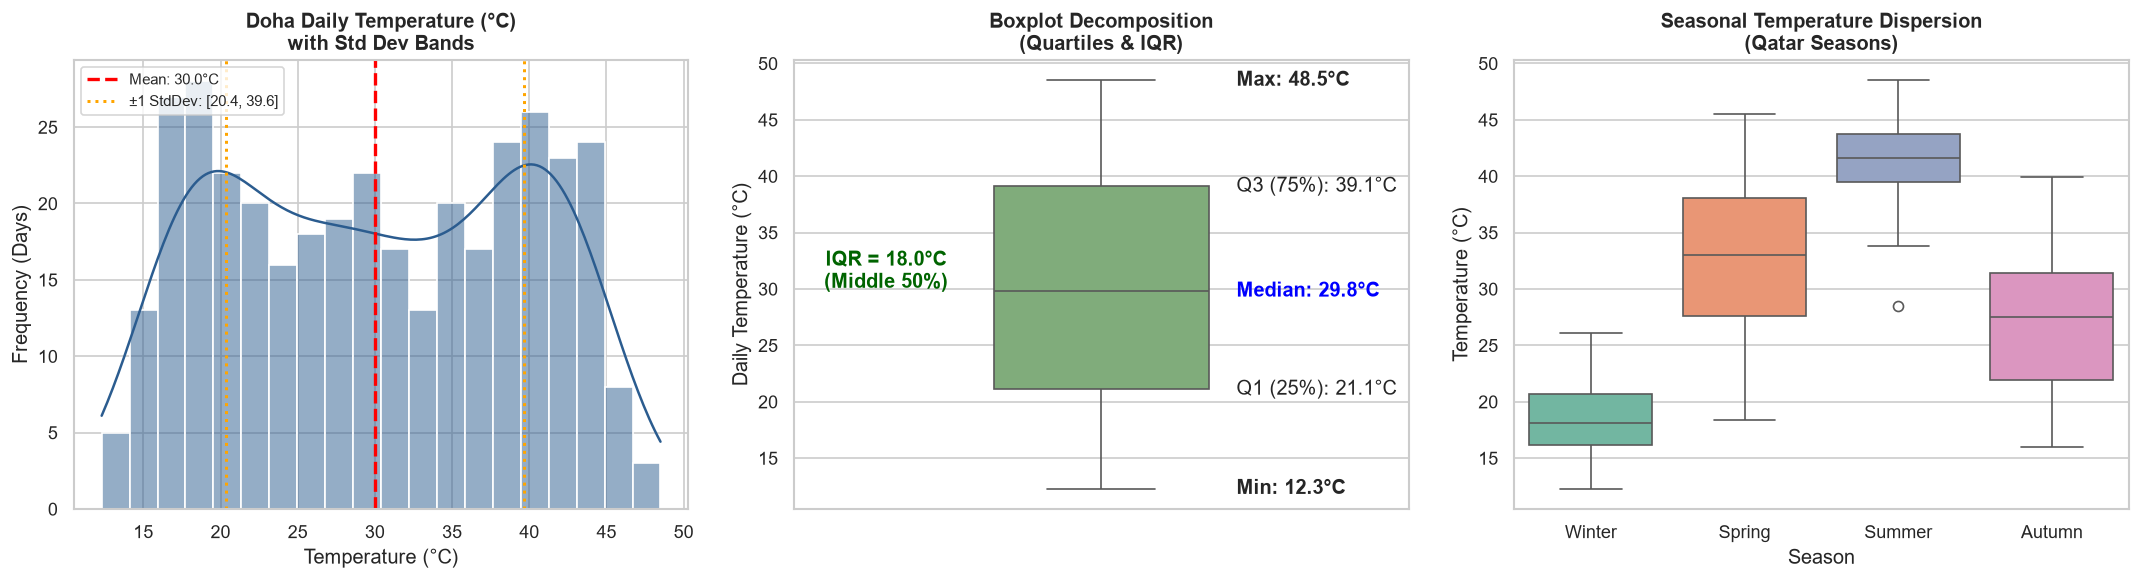

In [5]:
# Step 5: Multi-panel visualization of dispersion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Histogram with Mean & Standard Deviation Bands
sns.histplot(df_climate["temperature_c"], kde=True, color="#2b5c8f", bins=20, ax=axes[0])
axes[0].set_title("Doha Daily Temperature (°C)\nwith Std Dev Bands", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Frequency (Days)")

# Vertical lines for Mean and Standard Deviation intervals
axes[0].axvline(temp_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {temp_mean:.1f}°C")
axes[0].axvline(temp_mean - temp_std, color="orange", linestyle=":", linewidth=1.8, label=f"±1 StdDev: [{temp_mean-temp_std:.1f}, {temp_mean+temp_std:.1f}]")
axes[0].axvline(temp_mean + temp_std, color="orange", linestyle=":", linewidth=1.8)
axes[0].legend(loc="upper left", frameon=True, fontsize=9)

# Panel 2: Boxplot with labeled Quartiles & IQR
sns.boxplot(y=df_climate["temperature_c"], color="#79b473", width=0.35, ax=axes[1])
axes[1].set_title("Boxplot Decomposition\n(Quartiles & IQR)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Daily Temperature (°C)")

# Annotate boxplot milestones
axes[1].text(0.22, temp_max, f"Max: {temp_max:.1f}°C", verticalalignment="center", fontweight="bold")
axes[1].text(0.22, q3, f"Q3 (75%): {q3:.1f}°C", verticalalignment="center")
axes[1].text(0.22, df_climate['temperature_c'].median(), f"Median: {df_climate['temperature_c'].median():.1f}°C", verticalalignment="center", color="blue", fontweight="bold")
axes[1].text(0.22, q1, f"Q1 (25%): {q1:.1f}°C", verticalalignment="center")
axes[1].text(0.22, temp_min, f"Min: {temp_min:.1f}°C", verticalalignment="center", fontweight="bold")
axes[1].text(-0.35, (q1 + q3) / 2, f"IQR = {iqr:.1f}°C\n(Middle 50%)", color="darkgreen", fontweight="bold", ha="center")

# Panel 3: Seasonal Dispersion Comparison
season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df_climate, x="season", y="temperature_c", order=season_order, palette="Set2", ax=axes[2])
axes[2].set_title("Seasonal Temperature Dispersion\n(Qatar Seasons)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Season")
axes[2].set_ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

## 5. Seasonal Variability Analysis: Winter vs. Summer

Breaking down dispersion by season reveals how operational uncertainty shifts across the year.

In [6]:
# Step 6: Compute dispersion metrics grouped by Season
seasonal_dispersion = df_climate.groupby("season")["temperature_c"].agg(
    Days="count",
    Mean_Temp="mean",
    Std_Dev="std",
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Min="min",
    Max="max",
    Range=lambda x: x.max() - x.min()
).loc[season_order].reset_index()

print("=== Seasonal Dispersion Metrics for Doha Climate ===")
seasonal_dispersion.round(2)

=== Seasonal Dispersion Metrics for Doha Climate ===


,season,Days,Mean_Temp,Std_Dev,IQR,Min,Max,Range
0,Winter,90,18.44,3.05,4.50,12.3,26.1,13.8
1,Spring,92,32.82,6.12,10.45,18.4,45.5,27.1
2,Summer,93,41.34,3.37,4.20,28.5,48.5,20.0
3,Autumn,90,27.02,5.75,9.48,16.0,39.9,23.9


## 6. Practical Data Analyst Insights for Qatar

### ⚡ Practical Applications in Infrastructure & Public Policy:
1. **Cooling Infrastructure Dimensioning**:
   * Peak summer cooling demand reaches over **800 MW** with a standard deviation of **~125 MW**. Sizing power stations solely for the mean demand (~470 MW) would result in widespread summer brownouts.
   * Standard deviation and upper quartiles ($Q_3$) determine the **spinning reserve capacity** required by Kahramaa.
2. **Occupational Health & Labour Regulations**:
   * Qatar's Ministry of Labour enforces outdoor work bans during summer afternoons (10:00 AM – 3:30 PM from June 1 to September 15).
   * Dispersion analysis of temperature and wet-bulb globe temperature (WBGT) directly supports occupational safety thresholds.
3. **Summary Comparison Guide**:

| Metric | Formula | Interpretation | Sensitivity to Extremes |
| :--- | :--- | :--- | :--- |
| **Range** | $\text{Max} - \text{Min}$ | Full span of observations | **Extreme** (determined solely by min and max) |
| **IQR** | $Q_3 - Q_1$ | Spread of typical middle 50% | **Low / Robust** (ignores outer tails) |
| **Variance** | $\frac{1}{N-1}\sum(x_i - \bar{x})^2$ | Mean squared deviation | **High** (squared units) |
| **Standard Deviation** | $\sqrt{\text{Variance}}$ | Average distance from mean in original units | **Moderate-High** (intuitive and actionable) |